### **Tic-Tac-Toe — Do Jogo Aleatório ao *Policy Gradient* ao Planeamento Model-Based**

Práticas **PL7** (ambiente, *features*, agentes aleatórios), **PL8** (REINFORCE com baseline) e **PL9** (Monte Carlo Tree Search).


In [1]:
import sys, os, math, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt

from AR1.envs.tictactoe import TicTacToeEnv, _winner
from AR1.features.tictactoe import encode_state, STATE_FEATURE_DIM
from AR1.experiments.tictactoe import play_game, play_game_vs_human, play_game_vs_human_widget
from AR1.agents.control.reinforce import ReinforceAgent
from AR1.experiments.reinforce_tictactoe import (
    train, make_reinforce_policy, evaluate_vs_random, _play_silent,
)
from AR1.agents.planning.mcts import MCTSAgent
from AR1.experiments.mcts_tictactoe import (
    make_mcts_policy,
    evaluate_vs_random as mcts_eval_vs_random,
    evaluate_mcts_vs_reinforce,
    evaluate_mcts_vs_mcts,
)
from AR1.policies.tictactoe import random_action as random_policy


---
#### **1. Dois agentes aleatórios a jogar (PL7)**

Antes de qualquer aprendizagem, vamos ver duas políticas completamente aleatórias a jogar uma partida.


In [2]:
env = TicTacToeEnv()
play_game(env, random_policy, random_policy)


Initial board:
. . .
. . .
. . .


Player X plays cell 8:
. . .
. . .
. . X


Player O plays cell 6:
. . .
. . .
O . X


Player X plays cell 7:
. . .
. . .
O X X


Player O plays cell 5:
. . .
. . O
O X X


Player X plays cell 1:
. X .
. . O
O X X


Player O plays cell 2:
. X O
. . O
O X X


Player X plays cell 0:
X X O
. . O
O X X


Player O plays cell 4:
X X O
. O O
O X X


O wins!


-1

In [3]:
# Statistics over 1000 random games
n = 1_000
outcomes = {1: 0, -1: 0, 0: 0}
for _ in range(n):
    state = env.reset()
    while not env.is_terminal(state):
        action = random_policy(env, state)
        state, _, _ = env.step(action)
    outcomes[_winner(state)] += 1

print(f"Over {n} random vs random games:")
print(f"  X wins: {outcomes[1]/n:.1%}  |  O wins: {outcomes[-1]/n:.1%}  |  Draws: {outcomes[0]/n:.1%}")


Over 1000 random vs random games:
  X wins: 56.4%  |  O wins: 29.9%  |  Draws: 13.7%


---
#### **2. O vector de *features* de 27 dimensões (PL7)**

Cada estado do tabuleiro é codificado **na perspetiva do jogador atual**:

| Conteúdo da célula | Codificação |
|---|---|
| Peça minha   | `[1, 0, 0]` |
| Adversário   | `[0, 1, 0]` |
| Vazia        | `[0, 0, 1]` |

9 células × 3 dimensões = **27 *features***.

Como o encoding é relativo, os mesmos pesos da política funcionam quer para X quer para O — essencial para *self-play*.


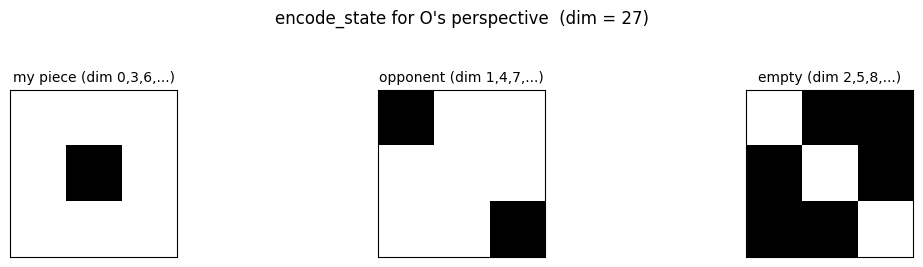

In [4]:
# Example board after three moves
#   X | . | .
#   . | O | .
#   . | . | X
sample_board = (1, 0, 0, 0, -1, 0, 0, 0, 1)
current_player = -1  # O's turn

phi = encode_state(sample_board, current_player)

fig, axes = plt.subplots(1, 3, figsize=(12, 2.5))
titles = ["my piece (dim 0,3,6,...)", "opponent (dim 1,4,7,...)", "empty (dim 2,5,8,...)"]
for ax, offset, title in zip(axes, range(3), titles):
    ax.imshow(phi[offset::3].reshape(3, 3), vmin=0, vmax=1, cmap="Greys")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"encode_state for O's perspective  (dim = {STATE_FEATURE_DIM})", y=1.05)
plt.tight_layout()
plt.show()


---
#### **3. Algoritmo REINFORCE (PL8)**

**Política softmax linear** ($\theta \in \mathbb{R}^{9 \times 27}$):

$$\pi(a|s) = \frac{e^{\theta_a \cdot \phi(s)}}{\sum_{b \in \mathcal{A}(s)} e^{\theta_b \cdot \phi(s)}}$$

***Self-play***: X e O partilham o mesmo $\theta$. As trajetórias são recolhidas separadamente por jogador; o último passo do perdedor é re-rotulado com $r = -1$ (o ambiente devolve $0$ numa derrota, pelo que sem isto o REINFORCE não teria sinal para se afastar de jogadas perdedoras).

***Baseline*** (Sutton & Barto, Sec. 13.4) reduz a variância do gradiente sem introduzir *bias*:

$$\delta_t = G_t - V(s_t) \qquad\qquad V(s) = w \cdot \phi(s)$$
$$\theta \mathrel{+}= \alpha \gamma^t\, \delta_t\, \nabla_\theta \log \pi(a_t|s_t)$$


---
#### **4. Treino**


In [5]:
SEED               = 42
NUM_EPISODES       = 50_000
ALPHA              = 0.005
GAMMA              = 1.0
ENTROPY_BETA       = 0.01
RANDOM_OPP_FRAC    = 0.3
EVAL_EVERY         = 2_000
EVAL_GAMES         = 500

env   = TicTacToeEnv()
agent = ReinforceAgent(
    alpha=ALPHA, gamma=GAMMA, entropy_beta=ENTROPY_BETA,
    use_baseline=True, seed=SEED,
)
results = train(
    agent,
    num_episodes=NUM_EPISODES,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_GAMES,
    random_opp_fraction=RANDOM_OPP_FRAC,
    seed=SEED,
)

print(f"Win rate as X: {results['win_rates_as_x'][-1]:.1%}")
print(f"Win rate as O: {results['win_rates_as_o'][-1]:.1%}")


Win rate as X: 88.6%
Win rate as O: 58.2%


---
#### **5. Curvas de aprendizagem**


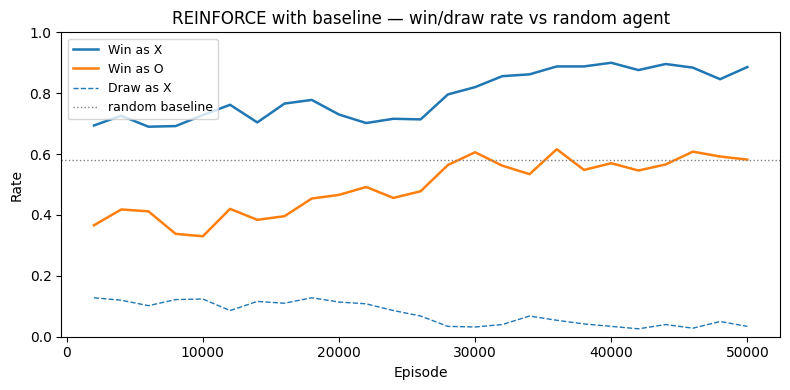

In [6]:
checkpoints = results["eval_checkpoints"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(checkpoints, results["win_rates_as_x"],  label="Win as X", color="tab:blue",   linewidth=1.8)
ax.plot(checkpoints, results["win_rates_as_o"],  label="Win as O", color="tab:orange",  linewidth=1.8)
ax.plot(checkpoints, results["draw_rates_as_x"], label="Draw as X", color="tab:blue",  linewidth=1, linestyle="--")
ax.axhline(0.58, color="grey", linestyle=":", linewidth=1, label="random baseline")
ax.set_xlabel("Episode"); ax.set_ylabel("Rate")
ax.set_title("REINFORCE with baseline — win/draw rate vs random agent")
ax.legend(fontsize=9); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


---
#### **6. Ver dois agentes treinados a jogar**

Tanto X como O usam a política ***greedy*** extraída do agente treinado.


In [7]:
reinforce_policy = make_reinforce_policy(agent, greedy=True)

print("=" * 40)
print(" REINFORCE (X)  vs  REINFORCE (O)")
print("=" * 40)
play_game(env, reinforce_policy, reinforce_policy, render=True)


 REINFORCE (X)  vs  REINFORCE (O)
Initial board:
. . .
. . .
. . .


Player X plays cell 4:
. . .
. X .
. . .


Player O plays cell 5:
. . .
. X O
. . .


Player X plays cell 8:
. . .
. X O
. . X


Player O plays cell 0:
O . .
. X O
. . X


Player X plays cell 7:
O . .
. X O
. X X


Player O plays cell 3:
O . .
O X O
. X X


Player X plays cell 1:
O X .
O X O
. X X


X wins!


1

In [8]:
n = 1_000
outcomes = {1: 0, -1: 0, 0: 0}
for _ in range(n):
    outcomes[_play_silent(env, reinforce_policy, reinforce_policy)] += 1

print(f"Over {n} self-play games:")
print(f"  X wins: {outcomes[1]/n:.1%}  |  O wins: {outcomes[-1]/n:.1%}  |  Draws: {outcomes[0]/n:.1%}")


Over 1000 self-play games:
  X wins: 100.0%  |  O wins: 0.0%  |  Draws: 0.0%


---
#### **7. Monte Carlo Tree Search (PL9)**

De ***model-free*** (REINFORCE — aprende pesos a partir da experiência) para ***model-based planning*** (MCTS — usa o próprio ambiente como modelo perfeito, planeia em tempo de decisão, sem treino):

|  | REINFORCE (model-free) | MCTS (model-based) |
|---|---|---|
| Precisa de treino?      | ✅ sim                          | ❌ não — procura em tempo de decisão |
| Usa modelo do ambiente? | ❌ só experiência real          | ✅ simula futuros internamente |
| Armazena conhecimento em | matriz de pesos $\theta$       | árvore de procura (descartada após cada jogada) |
| Custo computacional     | inicial (treino)                | por jogada (planeamento) |

Cada **simulação** do MCTS executa quatro fases:

1. **Seleção** — descer com UCB1 até chegar a um nó não totalmente expandido ou terminal:
$$\text{UCB1}(s,a) = -Q(s,a) + c\,\sqrt{\frac{\ln N(s)}{N(s,a)}}$$
   O sinal negativo em $Q$ existe porque pai e filho são **adversários** — o que é bom para o filho é mau para o pai.
2. **Expansão** — adicionar um novo filho para uma ação ainda não testada.
3. **Simulação** — *rollout* aleatório do novo nó até um estado terminal.
4. **Backup** — propagar o resultado pela árvore, invertendo o sinal a cada nível (os adversários alternam).

Seleção da ação: **filho mais visitado** da raiz (*robust best* — menos sensível a *outliers* dos rollouts do que $\arg\max Q$).


---
#### **8. MCTS em ação — sem treino necessário**

Ao contrário do REINFORCE, o MCTS está pronto a jogar imediatamente.


In [9]:
mcts_agent  = MCTSAgent(n_simulations=1_000)
mcts_policy = make_mcts_policy(mcts_agent)

print("=" * 40)
print(" MCTS (X)  vs  Random (O)")
print("=" * 40)
play_game(env, mcts_policy, random_policy, render=True)


 MCTS (X)  vs  Random (O)
Initial board:
. . .
. . .
. . .


Player X plays cell 4:
. . .
. X .
. . .


Player O plays cell 6:
. . .
. X .
O . .


Player X plays cell 7:
. . .
. X .
O X .


Player O plays cell 2:
. . O
. X .
O X .


Player X plays cell 1:
. X O
. X .
O X .


X wins!


1

---
#### **9. Efeito do orçamento de simulações**

Mais simulações → procura mais profunda → jogo mais forte, ao custo de mais tempo por jogada.


In [10]:
sim_counts = [10, 50, 100, 200, 500, 1000]
win_x, win_o, times = [], [], []
N_EVAL = 100   # keep small so the notebook stays responsive

for n in sim_counts:
    a = MCTSAgent(n_simulations=n)
    t0 = time.time()
    wx, _, _ = mcts_eval_vs_random(env, a, n_games=N_EVAL, as_player=1)
    wo, _, _ = mcts_eval_vs_random(env, a, n_games=N_EVAL, as_player=-1)
    elapsed = time.time() - t0
    win_x.append(wx); win_o.append(wo); times.append(elapsed)
    print(f"  n_sims={n:<5d}  win(X)={wx:.0%}  win(O)={wo:.0%}  ({elapsed:.1f}s)")


  n_sims=10     win(X)=92%  win(O)=69%  (0.2s)
  n_sims=50     win(X)=99%  win(O)=79%  (0.8s)
  n_sims=100    win(X)=99%  win(O)=86%  (1.6s)
  n_sims=200    win(X)=98%  win(O)=85%  (3.5s)
  n_sims=500    win(X)=99%  win(O)=95%  (8.5s)
  n_sims=1000   win(X)=99%  win(O)=90%  (17.7s)


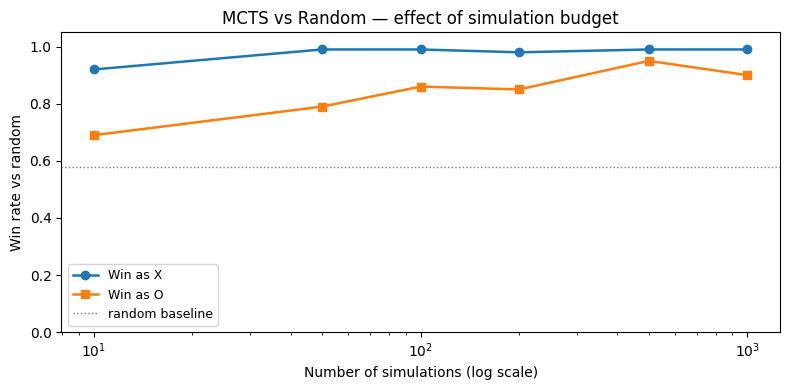

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sim_counts, win_x, "o-", color="tab:blue",   linewidth=1.8, label="Win as X")
ax.plot(sim_counts, win_o, "s-", color="tab:orange", linewidth=1.8, label="Win as O")
ax.axhline(0.58, color="grey", linestyle=":", linewidth=1, label="random baseline")
ax.set_xscale("log")
ax.set_xlabel("Number of simulations (log scale)"); ax.set_ylabel("Win rate vs random")
ax.set_title("MCTS vs Random — effect of simulation budget")
ax.legend(fontsize=9); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


---
#### **10. MCTS vs REINFORCE treinado**

Colocar um MCTS *fresco* (sem treino) contra o agente REINFORCE que treinámos na Secção 4.


In [12]:
mcts_strong = MCTSAgent(n_simulations=500)
N = 100

w_x, d_x, l_x = evaluate_mcts_vs_reinforce(env, mcts_strong, reinforce_policy, n_games=N, mcts_as_player=1)
w_o, d_o, l_o = evaluate_mcts_vs_reinforce(env, mcts_strong, reinforce_policy, n_games=N, mcts_as_player=-1)

print(f"MCTS (500 sims) vs REINFORCE  over {N} games per role:")
print(f"  MCTS as X: win={w_x:.0%}  draw={d_x:.0%}  loss={l_x:.0%}")
print(f"  MCTS as O: win={w_o:.0%}  draw={d_o:.0%}  loss={l_o:.0%}")


MCTS (500 sims) vs REINFORCE  over 100 games per role:
  MCTS as X: win=100%  draw=0%  loss=0%
  MCTS as O: win=98%  draw=0%  loss=2%


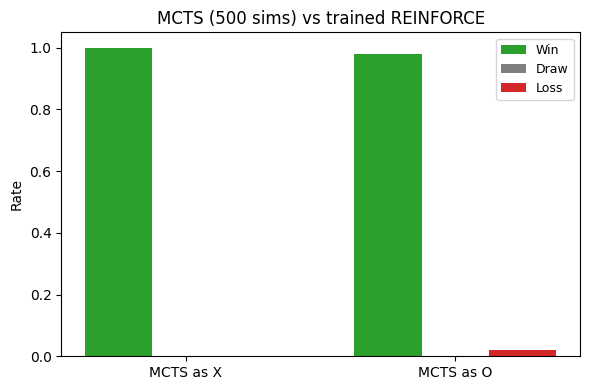

In [13]:
labels = ["MCTS as X", "MCTS as O"]
wins   = [w_x, w_o]; draws = [d_x, d_o]; losses = [l_x, l_o]
x = np.arange(len(labels)); width = 0.25

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width, wins,   width, label="Win",  color="tab:green")
ax.bar(x,         draws,  width, label="Draw", color="tab:grey")
ax.bar(x + width, losses, width, label="Loss", color="tab:red")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Rate"); ax.set_ylim(0, 1.05)
ax.set_title("MCTS (500 sims) vs trained REINFORCE")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
#### **11. MCTS vs MCTS — efeito do orçamento de simulações**

Dois agentes MCTS frente a frente. Dois padrões esperados:

1. **O orçamento importa.** Um `n_simulations` mais alto deve bater consistentemente um mais baixo — a árvore é mais profunda e mais precisa.
2. **Dois MCTS fortes empatam.** Tic-Tac-Toe é um jogo resolvido cujo resultado ótimo é empate; dois planeadores fortes convergem para o jogo ótimo de ambos os lados.


In [14]:
pairings = [(1000, 50), (1000, 200), (500, 500)]
N = 30

rows = []
for strong_n, weak_n in pairings:
    strong = MCTSAgent(n_simulations=strong_n)
    weak   = MCTSAgent(n_simulations=weak_n)
    wx, dx, lx = evaluate_mcts_vs_mcts(env, strong, weak, n_games=N, a_as_player=1)
    wo, do, lo = evaluate_mcts_vs_mcts(env, strong, weak, n_games=N, a_as_player=-1)
    rows.append((strong_n, weak_n, wx, dx, lx, wo, do, lo))
    print(f"MCTS({strong_n}) vs MCTS({weak_n})  (stronger's perspective)")
    print(f"  as X: win={wx:.0%}  draw={dx:.0%}  loss={lx:.0%}")
    print(f"  as O: win={wo:.0%}  draw={do:.0%}  loss={lo:.0%}")


MCTS(1000) vs MCTS(50)  (stronger's perspective)
  as X: win=60%  draw=40%  loss=0%
  as O: win=0%  draw=100%  loss=0%
MCTS(1000) vs MCTS(200)  (stronger's perspective)
  as X: win=7%  draw=93%  loss=0%
  as O: win=0%  draw=100%  loss=0%
MCTS(500) vs MCTS(500)  (stronger's perspective)
  as X: win=0%  draw=100%  loss=0%
  as O: win=0%  draw=90%  loss=10%


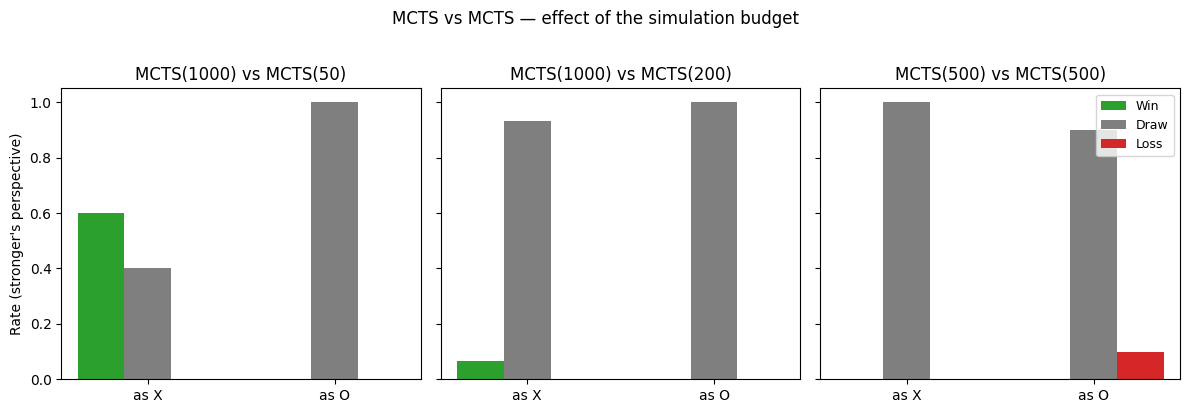

In [15]:
fig, axes = plt.subplots(1, len(rows), figsize=(4 * len(rows), 4), sharey=True)
if len(rows) == 1:
    axes = [axes]

for ax, (sn, wn, wx, dx, lx, wo, do, lo) in zip(axes, rows):
    labels = ["as X", "as O"]
    x = np.arange(len(labels)); width = 0.25
    ax.bar(x - width, [wx, wo], width, label="Win",  color="tab:green")
    ax.bar(x,         [dx, do], width, label="Draw", color="tab:grey")
    ax.bar(x + width, [lx, lo], width, label="Loss", color="tab:red")
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"MCTS({sn}) vs MCTS({wn})")

axes[0].set_ylabel("Rate (stronger's perspective)")
axes[-1].legend(fontsize=9, loc="upper right")
plt.suptitle("MCTS vs MCTS — effect of the simulation budget", y=1.02)
plt.tight_layout()
plt.show()


---
#### **12. Resumo — algoritmos comparados em Tic-Tac-Toe**

| Algoritmo | Tipo | Precisa de treino? | Win rate vs aleatório (como X) |
|---|---|:---:|:---:|
| Política aleatória         | Baseline                          | —  | ~58 % |
| REINFORCE + baseline       | Gradiente de política (model-free)| ✅ | ~96 % |
| MCTS (1000 sims)           | Planeamento model-based           | ❌ | ~100 % |

**Conclusão chave.** O planeamento model-based *com um simulador perfeito* bate a aprendizagem model-free num jogo pequeno e totalmente observável sem precisar de treino — mas cada jogada custa uma procura completa. Os métodos model-free amortizam esse custo à partida em pesos.


---
#### **13. Jogar contra o MCTS (UI interativa)**

A célula seguinte expõe o tabuleiro como uma grelha 3x3 de botões clicáveis. Cada botão mostra:

* O número da célula (`0` a `8`) enquanto está vazia.
* **`X`** a azul ou **`O`** a vermelho depois de jogada.

Clica numa célula para fazer a tua jogada — o MCTS responde imediatamente e o tabuleiro atualiza-se. O botão **"Novo jogo"** reinicia o tabuleiro a qualquer momento.

* `human_starts=True` — tu jogas como X (primeiro a mexer).
* `human_starts=False` — tu jogas como O (segundo a mexer).


In [16]:
from AR1.envs.tictactoe import TicTacToeEnv
env = TicTacToeEnv()

# UI interativa - clica nos botoes 0-8 para fazeres a tua jogada.
# Mete human_starts=False para deixar o MCTS comecar.
play_game_vs_human_widget(env, mcts_policy, human_starts=True, agent_label="MCTS")
